In [1]:
!pip install openpyxl

In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../data/moscow_transformed.xlsx").set_index(["ID на сайте", "Источник"], drop = False)
df.head()

,,ID на сайте,Источник,Название,Цена,Дата,Тип автора,Метро/Район,Адрес,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь
ID на сайте,Источник,,,,,,,,,,,,,,,,,
320731003,cian.ru,320731003,cian.ru,"Офис в Москва Шипиловская ул., 58к1 (25 м²)",38800,2025-08-23 02:23:27,Агентство,Шипиловская,"Шипиловская ул., 58к1",55.621211,37.745600,https://www.cian.ru/rent/commercial/320731003,['https://images.cdn-cian.ru/images/2592583348...,0.083,4.0,6.0,Офисное помещение,25.0
321876001,cian.ru,321876001,cian.ru,"Офис в Москва Ленинградский просп., 47С2 (25 м²)",31250,2025-09-25 20:21:36,Агентство,Аэропорт,"Ленинградский просп., 47С2",55.799036,37.532601,https://www.cian.ru/rent/commercial/321876001,['https://images.cdn-cian.ru/images/2631122267...,0.250,-2.0,7.0,Офисное помещение,25.0
322186790,cian.ru,322186790,cian.ru,"Офис в Москва Волгоградский просп., 2 (20 м²)",29200,2025-09-25 10:22:06,Агентство,Пролетарская,"Волгоградский просп., 2",55.731176,37.669279,https://www.cian.ru/rent/commercial/322186790,['https://images.cdn-cian.ru/images/2641248288...,0.250,6.0,16.0,Офисное помещение,20.0
321392086,cian.ru,321392086,cian.ru,Помещение свободного назначения в Москва ул. А...,32000,2025-09-02 04:23:10,Частное лицо,Бунинская Аллея,"ул. Адмирала Руднева, 20",55.540409,37.516153,https://www.cian.ru/rent/commercial/321392086,['https://images.cdn-cian.ru/images/nezhiloe-p...,0.250,3.0,7.0,Торговое / Свободного назначения,32.0
324943206,cian.ru,324943206,cian.ru,"Офис в Москва просп. Мира, 95С1 (24 м²)",44000,2025-12-11 16:28:22,Агентство,Алексеевская,"просп. Мира, 95С1",55.808002,37.635853,https://www.cian.ru/rent/commercial/324943206,['https://images.cdn-cian.ru/images/ofis-moskv...,0.167,14.0,17.0,Офисное помещение,24.0


In [3]:
df.dtypes

ID на сайте                         int64
Источник                           object
Название                           object
Цена                                int64
Дата                       datetime64[ns]
Тип автора                         object
Метро/Район                        object
Адрес                              object
lat                               float64
lng                               float64
URL                                object
Ссылки на картинки                 object
Расстояние до метро, км           float64
Этаж                              float64
Этажность здания                  float64
Вид объекта                        object
Общая площадь                     float64
dtype: object

In [4]:
df.columns

Index(['ID на сайте', 'Источник', 'Название', 'Цена', 'Дата', 'Тип автора',
       'Метро/Район', 'Адрес', 'lat', 'lng', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км', 'Этаж', 'Этажность здания', 'Вид объекта',
       'Общая площадь'],
      dtype='object')

In [5]:
df.isna().sum()

ID на сайте                  0
Источник                     0
Название                     0
Цена                         0
Дата                         0
Тип автора                   0
Метро/Район                  0
Адрес                        4
lat                          0
lng                          0
URL                          0
Ссылки на картинки         148
Расстояние до метро, км      0
Этаж                       123
Этажность здания           128
Вид объекта                  1
Общая площадь                0
dtype: int64

In [6]:
df = df.dropna(subset="Вид объекта")

In [7]:
df = df.drop(["Метро/Район", "Тип автора"], axis = 1)

# Трансформации

**Hack:** `OrdinalEncoder` нам создает некий ненужный порядок, которого у нас нет. Однако его можно ввести: достаточно понять влияние той или иной категории на таргет. Условно, делаем `TargetEncoding` -- назначаем метки по мере возрастания значения (дополнительно еще зашумляем и сглаживает). Так мы избегаем и сильной утечки таргета, и сохраняем важные данные.

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import TargetEncoder


class OrdinalByTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.te = TargetEncoder(target_type="continuous", random_state=10)

    def fit(self, X, y):
        self.te = self.te.fit(X, y)
        
    def transform(self, X, y=None):
        X_copy = X.copy()
        for i, col in enumerate(X.columns):
            cat_dict = dict(zip(self.te.categories_[i], self.te.encodings_[i]))
            ordinal_categories = sorted(cat_dict, key=cat_dict.get)
            ordinal_mapping = dict(zip(ordinal_categories, range(len(ordinal_categories))))
            X_copy[col] = X_copy[col].map(ordinal_mapping)
            X_copy[col] = X_copy[col].fillna(len(ordinal_categories) // 2)
        return X_copy

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def set_output(self, *, transform=None):
        """Scikit-learn 1.2+ requirement"""
        return self

In [9]:
data = pd.read_excel("data/geo_data.xlsx")
data = data.dropna(subset=["lat", "lon", "rubrics"])

In [10]:
from collections import Counter

data["rub_list"] = (
    data["rubrics"]
        .astype(str)
        .str.split(";")
        .apply(lambda x: [s.strip() for s in x if s.strip()])
)

all_rubrics = Counter(x for lst in data["rub_list"] for x in lst)
keep_rubrics = {k for k, v in all_rubrics.items() if v >= 100}

In [11]:
from sklearn.neighbors import BallTree

EARTH_R = 6371000.0

coords_data = np.radians(data[["lat", "lon"]].values)
tree = BallTree(coords_data, metric  = "haversine")

def get_lst(lat, lon, R_m):
    idxs = tree.query_radius(np.radians([[lat, lon]]), r = R_m / EARTH_R)[0]
    lst = {}
    for i in idxs:
        for r in data.iloc[i]["rub_list"]:
            if r in keep_rubrics:
                lst[r] = lst.get(r, 0) + 1
    return lst

R = 600

geo = []
for i, row in df.iterrows():
    geo.append(get_lst(row["lat"], row["lng"], R))

geo_df = pd.DataFrame(geo).fillna(0).astype(int)
geo_df.columns = [f"cnt_{c.replace(' ', '_')}" for c in geo_df.columns]
geo_cols = geo_df.columns.tolist()

df = pd.concat([df.reset_index(drop=True), geo_df.reset_index(drop=True)], axis=1)

In [12]:
data2 = pd.read_csv("data/moscow_super_ultra_transformed.csv").set_index(["ID на сайте", "Источник"])
data2 = data2.drop("Unnamed: 0", axis = 1)
data2

,,district_name,n_buildings_300m,n_living_buildings_300m,n_flats_300m,min_bc_distance_300m,mean_bc_distance_300m,traffic1_300m,traffic2_300m,traffic3_300m,traffic4_300m,...,Ветаптеки и ветклиники_600,Магазины цветов_600,"Прачечные, химчистки_600",Детские игровые залы_600,Религия_600,"Пиццерии, суши, столовые_600","Пекарни, кофейни_600","Кафе, бары, рестораны_600",Социальные_600,Банки_600
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,,,
320731003,cian.ru,Зябликово,38.0,14.0,3610.0,0.0,123.500000,8176.0,6091.0,1557.0,1713.0,...,8.0,8.0,7.0,0.0,0.0,3.0,7.0,11.0,8.0,1.0
321876001,cian.ru,Хорошевский,54.0,15.0,1287.0,0.0,82.666667,9392.0,38428.0,1513.0,11424.0,...,3.0,12.0,9.0,0.0,0.0,10.0,34.0,30.0,5.0,2.0
322186790,cian.ru,Таганский,44.0,22.0,3234.0,9.0,178.200000,8304.0,19462.0,2032.0,6787.0,...,10.0,17.0,15.0,0.0,1.0,11.0,29.0,29.0,10.0,2.0
321392086,cian.ru,Бутово Южное,23.0,8.0,1831.0,10.0,10.000000,4194.0,4593.0,2101.0,3820.0,...,1.0,6.0,3.0,0.0,1.0,4.0,7.0,9.0,5.0,0.0
324943206,cian.ru,Останкинский,46.0,30.0,3647.0,4.0,117.000000,7146.0,24972.0,4008.0,17350.0,...,6.0,8.0,15.0,0.0,1.0,16.0,27.0,29.0,10.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5510494944860968960,realty.yandex.ru,Теплый Стан,22.0,11.0,1906.0,0.0,0.000000,370.0,12038.0,1590.0,5384.0,...,2.0,4.0,3.0,0.0,0.0,6.0,7.0,9.0,5.0,0.0
5523185326772352000,realty.yandex.ru,Черемушки,26.0,7.0,1532.0,93.0,93.000000,364.0,4410.0,945.0,4851.0,...,3.0,6.0,3.0,0.0,6.0,10.0,6.0,5.0,8.0,1.0
5523185326772435968,realty.yandex.ru,Арбат,82.0,29.0,2233.0,0.0,154.066667,4312.0,57910.0,2106.0,13480.0,...,4.0,15.0,12.0,0.0,2.0,11.0,32.0,97.0,8.0,8.0


In [13]:
df = df.join(data2, on=["ID на сайте", "Источник"], how="left")
df

,ID на сайте,Источник,Название,Цена,Дата,Адрес,lat,lng,URL,Ссылки на картинки,...,Ветаптеки и ветклиники_600,Магазины цветов_600,"Прачечные, химчистки_600",Детские игровые залы_600,Религия_600,"Пиццерии, суши, столовые_600","Пекарни, кофейни_600","Кафе, бары, рестораны_600",Социальные_600,Банки_600
0,320731003,cian.ru,"Офис в Москва Шипиловская ул., 58к1 (25 м²)",38800,2025-08-23 02:23:27,"Шипиловская ул., 58к1",55.621211,37.745600,https://www.cian.ru/rent/commercial/320731003,['https://images.cdn-cian.ru/images/2592583348...,...,8.0,8.0,7.0,0.0,0.0,3.0,7.0,11.0,8.0,1.0
1,321876001,cian.ru,"Офис в Москва Ленинградский просп., 47С2 (25 м²)",31250,2025-09-25 20:21:36,"Ленинградский просп., 47С2",55.799036,37.532601,https://www.cian.ru/rent/commercial/321876001,['https://images.cdn-cian.ru/images/2631122267...,...,3.0,12.0,9.0,0.0,0.0,10.0,34.0,30.0,5.0,2.0
2,322186790,cian.ru,"Офис в Москва Волгоградский просп., 2 (20 м²)",29200,2025-09-25 10:22:06,"Волгоградский просп., 2",55.731176,37.669279,https://www.cian.ru/rent/commercial/322186790,['https://images.cdn-cian.ru/images/2641248288...,...,10.0,17.0,15.0,0.0,1.0,11.0,29.0,29.0,10.0,2.0
3,321392086,cian.ru,Помещение свободного назначения в Москва ул. А...,32000,2025-09-02 04:23:10,"ул. Адмирала Руднева, 20",55.540409,37.516153,https://www.cian.ru/rent/commercial/321392086,['https://images.cdn-cian.ru/images/nezhiloe-p...,...,1.0,6.0,3.0,0.0,1.0,4.0,7.0,9.0,5.0,0.0
4,324943206,cian.ru,"Офис в Москва просп. Мира, 95С1 (24 м²)",44000,2025-12-11 16:28:22,"просп. Мира, 95С1",55.808002,37.635853,https://www.cian.ru/rent/commercial/324943206,['https://images.cdn-cian.ru/images/ofis-moskv...,...,6.0,8.0,15.0,0.0,1.0,16.0,27.0,29.0,10.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9064,3987628968735107072,realty.yandex.ru,Офис (1200 м²),6000000,2025-09-05 16:00:52,"1-й Магистральный тупик, 5А",55.766132,37.531956,https://realty.ya.ru/offer/3987628968735107205/,NaN,...,7.0,6.0,0.0,0.0,0.0,9.0,10.0,2.0,1.0,1.0
9065,322424654,cian.ru,"Офис в Москва Сколковское ш., вл43 (1149 м²)",6894000,2025-10-03 08:21:53,"Сколковское ш., вл43",55.699654,37.397701,https://www.cian.ru/rent/commercial/322424654,['https://images.cdn-cian.ru/images/2650029058...,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,3.0,0.0,0.0
9066,7523548143730329600,realty.yandex.ru,Офис (967 м²),6769000,2025-10-22 07:59:36,"Сколковское шоссе, вл43",55.699654,37.397700,https://realty.ya.ru/offer/7523548143730329381/,['https://avatars.mds.yandex.net/get-realty-of...,...,3.0,2.0,1.0,0.0,1.0,0.0,7.0,7.0,4.0,0.0
9067,322670014,cian.ru,"Офис в Москва Сколковское ш., вл43 (1134 м²)",7938000,2025-10-11 14:21:23,"Сколковское ш., вл43",55.699654,37.397701,https://www.cian.ru/rent/commercial/322670014,['https://images.cdn-cian.ru/images/2658570375...,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,3.0,0.0,0.0


In [14]:
df = df.dropna(subset=["n_buildings_300m"])

In [15]:
num_cols_data2 = [
    "district_price",
    "traffic4_300m",
    "n_buildings_600m",
    "traffic1_600m",
    "n_buildings_300m"
]

str_cols_data2 = [
    "district_name",
]

geo_cols_mod = [
    "cnt_Бизнес-центр",
    "cnt_Ресторан",
    "cnt_Караоке-клуб",
    "cnt_Кондитерская",
    "cnt_Магазин_цветов",
    "cnt_Банк",
    "cnt_Кофейня"
]

In [16]:
from sklearn.model_selection import train_test_split

X = df[
    ["Общая площадь", "Расстояние до метро, км", "Этаж"]
    + ["Вид объекта"]
    + num_cols_data2
    + str_cols_data2 
    + geo_cols_mod
].copy()
X

,Общая площадь,"Расстояние до метро, км",Этаж,Вид объекта,district_price,traffic4_300m,n_buildings_600m,traffic1_600m,n_buildings_300m,district_name,cnt_Бизнес-центр,cnt_Ресторан,cnt_Караоке-клуб,cnt_Кондитерская,cnt_Магазин_цветов,cnt_Банк,cnt_Кофейня
0,25.0,0.083,4.0,Офисное помещение,281700.0,1713.0,157.0,8176.0,38.0,Зябликово,0,1,0,3,3,0,1
1,25.0,0.250,-2.0,Офисное помещение,443000.0,11424.0,253.0,9392.0,54.0,Хорошевский,0,6,0,6,4,1,7
2,20.0,0.250,6.0,Офисное помещение,433700.0,6787.0,223.0,8304.0,44.0,Таганский,0,9,1,2,0,4,8
3,32.0,0.250,3.0,Торговое / Свободного назначения,259700.0,3820.0,107.0,4194.0,23.0,Бутово Южное,0,3,0,1,0,1,1
4,24.0,0.167,14.0,Офисное помещение,380300.0,17350.0,216.0,7146.0,46.0,Останкинский,0,11,0,3,2,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9064,1200.0,11.917,4.0,Офисное помещение,443000.0,10815.0,190.0,432.0,49.0,Хорошевский,1,0,0,0,0,0,0
9065,1149.0,7.333,1.0,Офисное помещение,311900.0,0.0,35.0,4306.0,7.0,Можайский,0,0,0,0,0,0,0
9066,967.0,18.333,3.0,Офисное помещение,483300.0,1232.0,76.0,510.0,20.0,Раменки,0,0,0,0,0,0,0
9067,1134.0,7.333,2.0,Офисное помещение,311900.0,0.0,35.0,4306.0,7.0,Можайский,0,0,0,0,0,0,0


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, # OrdinalEncoder, TargetEncoder,
    StandardScaler, # MinMaxScaler, RobustScaler,
)

from sklearn import set_config
set_config(transform_output="pandas")

ct = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(),["Общая площадь", "Расстояние до метро, км", "Этаж"] + geo_cols_mod + num_cols_data2),
        ("onehot", OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore"), ["Вид объекта"] + str_cols_data2),
        ("ordinal", OrdinalByTargetEncoder(), ["district_name"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
    verbose_feature_names_out = False
).set_output(transform="pandas")

In [18]:
y = df["Цена"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = X["Вид объекта"], random_state = 42)
X_train

,Общая площадь,"Расстояние до метро, км",Этаж,Вид объекта,district_price,traffic4_300m,n_buildings_600m,traffic1_600m,n_buildings_300m,district_name,cnt_Бизнес-центр,cnt_Ресторан,cnt_Караоке-клуб,cnt_Кондитерская,cnt_Магазин_цветов,cnt_Банк,cnt_Кофейня
2859,72.0,0.500,4.0,Офисное помещение,385200.0,1450.0,155.0,996.0,45.0,Бутырский,1,27,4,11,11,10,16
8852,1050.0,0.917,1.0,Офисное помещение,414000.0,6112.0,219.0,836.0,70.0,Беговой,0,10,2,1,2,2,2
6733,419.0,0.333,2.0,Офисное помещение,530600.0,8901.0,564.0,292.0,136.0,Мещанский,1,49,2,5,5,6,9
4258,222.0,0.917,1.0,Офисное помещение,397600.0,11472.0,208.0,790.0,71.0,Алексеевский,0,0,0,1,1,2,2
338,32.0,1.000,2.0,Торговое / Свободного назначения,291400.0,40.0,37.0,958.0,13.0,Коммунарка,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6237,609.0,0.750,4.0,Офисное помещение,327500.0,3669.0,169.0,0.0,48.0,Бескудниковский,0,0,0,0,0,0,1
9009,1500.0,1.500,3.0,Офисное помещение,300500.0,607.0,136.0,0.0,42.0,Москворечье-Сабурово,0,2,0,0,0,0,3
2781,56.0,0.667,6.0,Офисное помещение,326200.0,28894.0,111.0,130.0,20.0,Зюзино,1,1,0,1,1,0,0
4393,342.0,0.667,-1.0,Торговое / Свободного назначения,399100.0,12168.0,165.0,326.0,63.0,Даниловский,0,15,0,4,0,1,4


In [19]:
X_train["Вид объекта"].value_counts() / X_train.shape[0] * 100

Вид объекта
Офисное помещение                   65.506698
Торговое / Свободного назначения    33.313920
Здание                               1.179383
Name: count, dtype: float64

In [20]:
X_test["Вид объекта"].value_counts() / X_test.shape[0] * 100

Вид объекта
Офисное помещение                   65.483120
Торговое / Свободного назначения    33.294529
Здание                               1.222352
Name: count, dtype: float64

In [21]:
X_train.isna().sum()

Общая площадь               0
Расстояние до метро, км     0
Этаж                       95
Вид объекта                 0
district_price              0
traffic4_300m               0
n_buildings_600m            0
traffic1_600m               0
n_buildings_300m            0
district_name              16
cnt_Бизнес-центр            0
cnt_Ресторан                0
cnt_Караоке-клуб            0
cnt_Кондитерская            0
cnt_Магазин_цветов          0
cnt_Банк                    0
cnt_Кофейня                 0
dtype: int64

In [22]:
X_test.isna().sum()

Общая площадь               0
Расстояние до метро, км     0
Этаж                       28
Вид объекта                 0
district_price              0
traffic4_300m               0
n_buildings_600m            0
traffic1_600m               0
n_buildings_300m            0
district_name               3
cnt_Бизнес-центр            0
cnt_Ресторан                0
cnt_Караоке-клуб            0
cnt_Кондитерская            0
cnt_Магазин_цветов          0
cnt_Банк                    0
cnt_Кофейня                 0
dtype: int64

In [23]:
floor_mode = X_train["Этаж"].mode().values[0]
X_train["Этаж"] = X_train["Этаж"].fillna(floor_mode)
X_test["Этаж"] = X_test["Этаж"].fillna(floor_mode)

In [24]:
ct = ct.fit(X_train, y_train)
X_train_base = ct.transform(X_train)
X_test_base = ct.transform(X_test)

X_train_base

,Общая площадь,"Расстояние до метро, км",Этаж,cnt_Бизнес-центр,cnt_Ресторан,cnt_Караоке-клуб,cnt_Кондитерская,cnt_Магазин_цветов,cnt_Банк,cnt_Кофейня,...,district_name_Чертаново Центральное,district_name_Чертаново Южное,district_name_Щербинка,district_name_Щукино,district_name_Южнопортовый,district_name_Якиманка,district_name_Ярославский,district_name_Ясенево,district_name_nan,district_name
2859,-0.682953,-0.325040,-0.010341,0.278222,0.497266,2.042269,2.623143,4.218225,3.128140,1.558716,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,95
8852,1.896838,-0.154389,-0.441652,-0.714932,-0.240420,0.733784,-0.407872,0.068346,0.053167,-0.507509,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99
6733,0.232372,-0.393382,-0.297882,0.278222,1.451919,0.733784,0.804534,1.451639,1.590654,0.525603,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,113
4258,-0.287280,-0.154389,-0.441652,-0.714932,-0.674353,-0.574701,-0.407872,-0.392752,0.053167,-0.507509,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,66
338,-0.788466,-0.120423,-0.297882,-0.714932,-0.674353,-0.574701,-0.710973,-0.853850,-0.715576,-0.655097,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6237,0.733558,-0.222731,-0.010341,-0.714932,-0.674353,-0.574701,-0.710973,-0.853850,-0.715576,-0.655097,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82
9009,3.083859,0.084194,-0.154111,-0.714932,-0.587566,-0.574701,-0.710973,-0.853850,-0.715576,-0.359922,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62
2781,-0.725158,-0.256698,0.277200,0.278222,-0.630959,-0.574701,-0.407872,-0.392752,-0.715576,-0.802684,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,107
4393,0.029259,-0.256698,-0.729193,-0.714932,-0.023453,-0.574701,0.501433,-0.853850,-0.331204,-0.212334,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,111


# Модель

In [25]:
from sklearn.metrics import (
    r2_score,
    root_mean_squared_error as rmse,
    mean_absolute_percentage_error as mape,
)

def print_metrics(y_true, y_pred, dataset):
    print(f"{dataset} metrics:")
    print(f"\t  R2: {r2_score(y_true, y_pred) * 100:.2f}%")
    print(f"\tRMSE: {rmse(y_true, y_pred):.2f} руб.")
    print(f"\tMAPE: {mape(y_true, y_pred) * 100:.2f}%")

In [26]:
import sys

sys.path.append("..")

import viz

In [27]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(verbose=False).fit(X_train_base, y_train)
y_pred = model.predict(X_train_base)
y_test_pred = model.predict(X_test_base)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

train metrics:
	  R2: 96.03%
	RMSE: 282877.01 руб.
	MAPE: 28.42%

test metrics:
	  R2: 88.73%
	RMSE: 475877.34 руб.
	MAPE: 34.41%


In [28]:
!pip install shap

In [29]:
import shap

explainer = shap.TreeExplainer(model)

N_SAMPLE = df.shape[0]
if X_train_base.shape[0] > N_SAMPLE:
    X_shap = X_train_base.sample(N_SAMPLE, random_state = 42)
else:
    X_shap = X_train_base

shap_values = explainer.shap_values(X_shap)
shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)
shap_imp

C:\Users\timof\miniconda3\envs\sirius\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Общая площадь                       871682.759855
district_name                       101070.176032
district_price                       65624.818381
cnt_Ресторан                         60856.475548
traffic4_300m                        54477.029575
                                        ...      
district_name_Ховрино                    0.000000
district_name_Чертаново Северное         0.000000
district_name_Щербинка                   0.000000
district_name_Якиманка                   0.000000
district_name_Ярославский                0.000000
Length: 146, dtype: float64

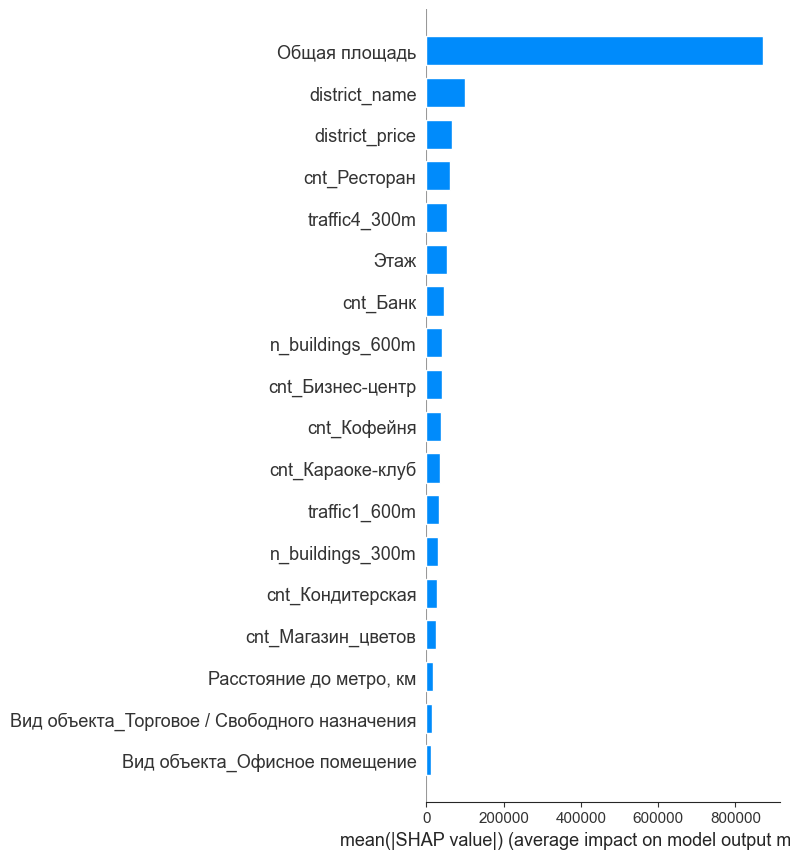

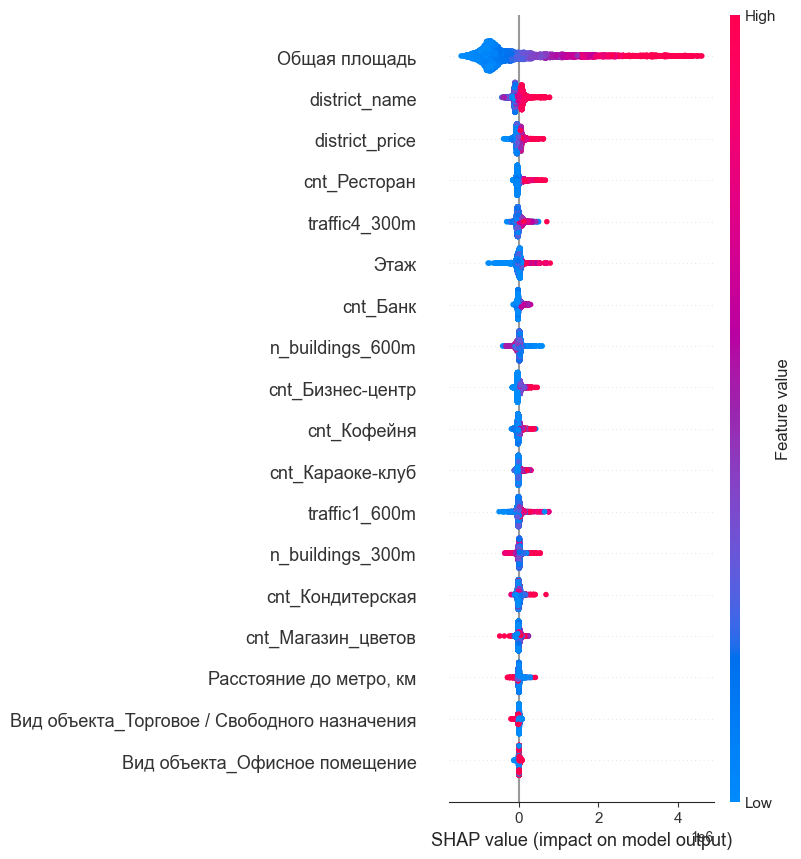

In [30]:
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=18)
shap.summary_plot(shap_values, X_shap, plot_type="dot", max_display=18)

In [31]:
n = 18
top_n_features = shap_imp.head(n).index.tolist()

print("Top", n, "features:", top_n_features)

X_train_top = X_train_base[top_n_features]
X_test_top  = X_test_base[top_n_features]

from catboost import CatBoostRegressor

model_top = CatBoostRegressor(verbose=False)
model_top.fit(X_train_top, y_train)

y_pred_train = model_top.predict(X_train_top)
y_pred_test  = model_top.predict(X_test_top)

print_metrics(y_train, y_pred_train, "train")
print()
print_metrics(y_test, y_pred_test, "test")

Top 18 features: ['Общая площадь', 'district_name', 'district_price', 'cnt_Ресторан', 'traffic4_300m', 'Этаж', 'cnt_Банк', 'n_buildings_600m', 'cnt_Бизнес-центр', 'cnt_Кофейня', 'cnt_Караоке-клуб', 'traffic1_600m', 'n_buildings_300m', 'cnt_Кондитерская', 'cnt_Магазин_цветов', 'Расстояние до метро, км', 'Вид объекта_Торговое / Свободного назначения', 'Вид объекта_Офисное помещение']
train metrics:
	  R2: 96.57%
	RMSE: 262777.56 руб.
	MAPE: 27.34%

test metrics:
	  R2: 88.69%
	RMSE: 476750.35 руб.
	MAPE: 33.65%
